# 01 — Data prep: Sentinel-2 scene search (Ghana, Jan–May 2025)

First step of the pipeline: search Microsoft Planetary Computer for `sentinel-2-l2a` scenes over Ghana in the dry-season window, apply a coarse cloud-cover filter, tighten the results against Ghana's real boundary (dropping scenes that only clip the search bbox — e.g. mostly ocean or a neighboring country), and save the resulting scene list for the next notebook to refine further (per-AOI SCL cloud/shadow fraction + haze filtering, land-cover stratification, patch extraction).

See `agents.md` for the reasoning behind the AOI, date range, data source, and filtering approach.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import pandas as pd

# repo root is the parent of this notebooks/ directory
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from s2sr import config, stac

In [3]:
print("AOI bbox:", config.GHANA_BBOX)
print("Date range:", config.DATETIME_RANGE)
print("Collection:", config.S2_COLLECTION)
print("Max cloud cover (coarse filter):", config.MAX_CLOUD_COVER)

AOI bbox: (-3.262441, 4.736723, 1.191781, 11.173301)
Date range: 2025-01-01/2025-05-31
Collection: sentinel-2-l2a
Max cloud cover (coarse filter): 20


In [4]:
items = stac.search_scenes()
len(items)

850

In [5]:
scenes_all = stac.items_to_dataframe(items)
scenes_all.head()

,id,datetime,mgrs_tile,cloud_cover,geometry
0,S2B_MSIL2A_20250110T102319_R065_T30NVL_2025011...,2025-01-10T10:23:19.024000Z,30NVL,17.861423,"POLYGON ((-3.13295 4.43478, -3.10157 4.57794, ..."
1,S2B_MSIL2A_20250113T103309_R108_T30NVL_2025011...,2025-01-13T10:33:09.024000Z,30NVL,13.852586,"POLYGON ((-2.91201 4.54614, -2.93674 4.43489, ..."
2,S2A_MSIL2A_20250115T102351_R065_T30NVL_2025011...,2025-01-15T10:23:51.024000Z,30NVL,5.746395,"POLYGON ((-3.12885 4.43478, -3.10829 4.5289, -..."
3,S2B_MSIL2A_20250120T102239_R065_T30NVL_2025012...,2025-01-20T10:22:39.024000Z,30NVL,17.287284,"POLYGON ((-3.13446 4.43478, -3.11708 4.51395, ..."
4,S2C_MSIL2A_20250204T102251_R065_T30NVL_2025020...,2025-02-04T10:22:51.025000Z,30NVL,17.769678,"POLYGON ((-3.14385 4.43477, -3.12715 4.5109, -..."


Matplotlib is building the font cache; this may take a moment.


<Axes: >

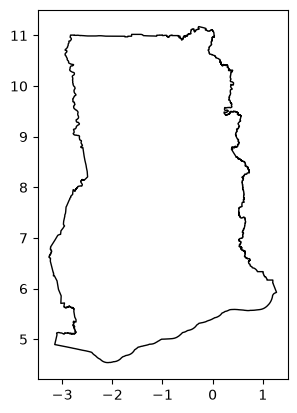

In [6]:
from s2sr import boundaries

ghana_boundary = boundaries.fetch_country_boundary("Ghana", config.GHANA_BOUNDARY_PATH)
ghana_boundary.plot(edgecolor="black", facecolor="none")

In [7]:
df = stac.filter_by_aoi(scenes_all)

dropped_tiles = sorted(set(scenes_all["mgrs_tile"]) - set(df["mgrs_tile"]))
print(f"Before AOI filtering: {len(scenes_all)} scenes, {scenes_all['mgrs_tile'].nunique()} tiles")
print(f"After AOI filtering:  {len(df)} scenes, {df['mgrs_tile'].nunique()} tiles")
print(f"Tiles dropped entirely: {dropped_tiles}")

Before AOI filtering: 850 scenes, 53 tiles
After AOI filtering:  657 scenes, 41 tiles
Tiles dropped entirely: ['30PVQ', '30PVR', '30PVS', '30PVT', '31NBF', '31NCH', '31NCJ', '31PBN', '31PCK', '31PCL', '31PCM', '31PCN']


In [8]:
# Coverage check: how many candidate scenes per MGRS tile, after AOI tightening?
df.groupby("mgrs_tile").size().sort_values(ascending=False)

mgrs_tile
30PXR    34
30PWR    34
30PXQ    32
30PXT    30
30PWQ    29
30PXS    28
31NBJ    27
30NZL    25
31PBL    24
30PZR    22
30PZQ    21
31PBM    21
31PBK    21
30NZP    21
30PZS    20
30PZT    20
30PYT    18
30NWP    18
30NZN    18
30NYL    15
30PYS    15
30NYP    15
30PWS    14
30PYR    13
30NXP    12
30NZM    12
30PYQ    12
30PWT    10
30NYM    10
30NVL    10
30NYN     8
30NWN     8
31NBH     7
31NBG     6
30NVP     5
30NWL     5
30NXN     5
30NWM     4
30NXL     4
30NXM     3
30NVN     1
dtype: int64

In [9]:
# Coverage check: how many candidate scenes per month?
month = pd.to_datetime(df["datetime"]).dt.to_period("M")
df.assign(month=month).groupby("month").size()

C:\Users\zutad\AppData\Local\Temp\ipykernel_16604\1689059137.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month = pd.to_datetime(df["datetime"]).dt.to_period("M")


month
2025-01    232
2025-02    129
2025-03    102
2025-04    109
2025-05     85
Freq: M, dtype: int64

## Next steps (not yet implemented in this notebook)

- Per-AOI cloud/shadow/snow fraction from the SCL band (whole-granule `eo:cloud_cover` above is only a coarse pass).
- Harmattan haze check (Dec–Feb especially) — not flagged by SCL, needs a separate NDVI/reflectance-based check.
- Land-cover stratified tile/date selection across all Ghana MGRS tiles.
- Patch extraction with Wald's protocol (128×128 px @ 10m, downsample factors 2× / 6×).

These land in a follow-up notebook once this scene list is reviewed.

In [ ]:
out_path = REPO_ROOT / "data" / "interim" / "s2_scenes_ghana_2025_dry_season.geojson"
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_file(out_path, driver="GeoJSON")
out_path